Filtragem do sinal

In [4]:
import pandas as pd
import numpy as np
from scipy.signal import butter, sosfilt, iirnotch, sosfiltfilt, filtfilt

# ======================
# CONFIGURAÇÕES
# ======================
fs = 500  # taxa de amostragem
lowcut = 20
highcut = 240
notch_freq = 60

# ======================
# CARREGAR DADOS
# ======================
df = pd.read_csv("new_emg_data8.csv")
signal = df["EMG_Value"].values

# ======================
# 1. FILTRO NOTCH 60 Hz
# ======================
Q = 30  # fator de qualidade (quanto maior, mais estreito)
b_notch, a_notch = iirnotch(notch_freq, Q, fs)

signal_notch = np.zeros_like(signal)
signal_notch = np.convolve(signal, b_notch, mode='same')  # alternativa leve


signal_notch = filtfilt(b_notch, a_notch, signal)

# ======================
# 2. FILTRO PASSA-FAIXA
# ======================
sos = butter(4, [lowcut, highcut], btype='bandpass', fs=fs, output='sos')

signal_filtered = sosfiltfilt(sos, signal_notch)

print("Filtragem concluída!")


Filtragem concluída!


Plot dos sinais cru e filtrado

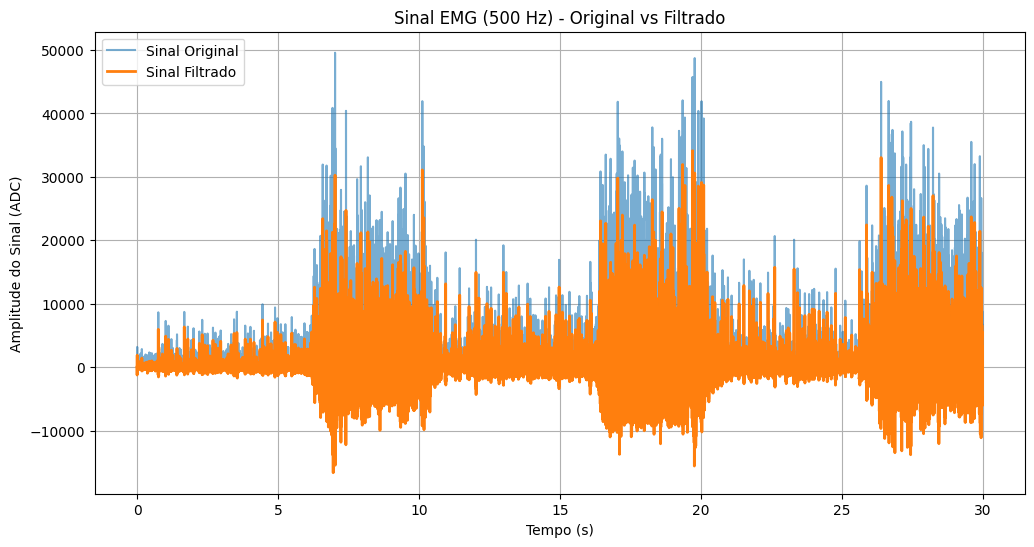

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.signal import butter, sosfilt, iirnotch, sosfiltfilt


# =========================
# CONFIGURAÇÃO
# =========================
fs = 500  # taxa de amostragem

# =========================
# EIXO DO TEMPO
# =========================
t = np.arange(len(signal)) / fs

# =========================
# PLOT
# =========================
plt.figure(figsize=(12, 6))

plt.plot(t, signal, label="Sinal Original", alpha=0.6)
plt.plot(t, signal_filtered, label="Sinal Filtrado", linewidth=2)

plt.xlabel("Tempo (s)")
plt.ylabel("Amplitude do Sinal (ADC)")
plt.title("Sinal EMG (500 Hz) - Original vs Filtrado")
plt.legend()
plt.grid()

plt.show()

fft do sinal filtrado

In [6]:
import numpy as np
import plotly.graph_objects as go

# Assuming signal_filtered4 and fs are available from previous cells
# If not, you would load the data and filter it here.

# Perform FFT on the filtered signal
N = len(signal_filtered) # Number of samples
yf = np.fft.fft(signal_filtered)
xf = np.fft.fftfreq(N, 1 / fs) # Frequency bins

# Apply user's requested calculation
pos_mask = xf > 0
freqs_pos = xf[pos_mask]
fft_magnitude_raw = np.abs(yf[pos_mask]) * 2

# Scale magnitude for plotting as requested by the user
fft_magnitude_scaled = fft_magnitude_raw / 1e6 # Dividing by 10^6

# Plot the magnitude spectrum (only positive frequencies) using Plotly
fig = go.Figure(data=[go.Scatter(
    x=freqs_pos,
    y=fft_magnitude_scaled,
    mode='lines',
    name='Magnitude'
)])

fig.update_layout(
    title="Espectro de Magnitude do Sinal EMG Filtrado (FFT)",
    xaxis_title="Frequência (Hz)",
    yaxis_title="Magnitude (x 10^6)", # Updated label
    xaxis_range=[0, fs / 2] # Limit to Nyquist frequency
)

fig.show()

fft do sinal cru

In [10]:
import numpy as np
import plotly.graph_objects as go

# Assuming signal_filtered4 and fs are available from previous cells
# If not, you would load the data and filter it here.

# Perform FFT on the filtered signal
N = len(signal) # Number of samples
yf = np.fft.fft(signal)
xf = np.fft.fftfreq(N, 1 / fs) # Frequency bins

# Apply user's requested calculation
pos_mask = xf > 0
freqs_pos = xf[pos_mask]
fft_magnitude_raw = np.abs(yf[pos_mask]) * 2

# Scale magnitude for plotting as requested by the user
fft_magnitude_scaled = fft_magnitude_raw / 1e6 # Dividing by 10^6

# Plot the magnitude spectrum (only positive frequencies) using Plotly
fig = go.Figure(data=[go.Scatter(
    x=freqs_pos,
    y=fft_magnitude_scaled,
    mode='lines',
    name='Magnitude'
)])

fig.update_layout(
    title="Espectro de Magnitude do Sinal EMG Filtrado (FFT)",
    xaxis_title="Frequência (Hz)",
    yaxis_title="Magnitude (x 10^6)", # Updated label
    xaxis_range=[0, fs / 2], # Limit to Nyquist frequency
    yaxis_range = [0, 4]
)

fig.show()

Foi utilizado os mesmos códigos para o sinal com fs = 1000 HZ